# v7 — Residual Connections + LayerNorm (+ a wider feed-forward)

This builds directly on **v6**. Steps 1–10 below carry over as-is (setup, `Head`).

What's new — this is the change that makes it possible to stack many blocks and still train:

1. **Output projection** in `MultiHeadAttention`: after concatenating the heads, project back through a linear layer (`self.proj`).
2. **Wider feed-forward**: the MLP now expands to `4 * emb_size` in its hidden layer before projecting back down to `emb_size` — the standard transformer FFN shape.
3. **Residual connections + pre-norm** in `TransformerBlock`: instead of overwriting `x`, we add each sublayer's output back onto `x` (`x = x + sublayer(LayerNorm(x))`). This residual *stream* is what makes deep transformers trainable — gradients can flow straight through the `+`, bypassing the attention/feed-forward computations if needed.
4. A final `LayerNorm` after the stack of blocks, right before the `linear_head`.

## 1. Imports

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F

## 2. Hyperparameters

In [2]:
# emb_size = 32        # embedding size for each token
# batch_size = 32      # how many independent sequences will we process in parallel?
# block_size = 8       # what is the maximum context length for predictions?
# max_iters = 10000    # maximum number of iterations for training
# eval_interval = 500  # interval for evaluating the model
# learning_rate = 1e-3 # learning rate for training
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# eval_iters = 200     # number of iterations for evaluation
# seed = 42            # seed for reproducibility

# torch.manual_seed(seed)

In [3]:
# Sabine's version of the above block that does hardware detection (that way on Mac it uses GPU if available rather than CPU default)
# Detect best available device (CUDA>MPS>CPU) and set DataLoader workers accordingly
import os

emb_size = 32        # embedding size for each token
batch_size = 32      # how many independent sequences will we process in parallel?
block_size = 8       # what is the maximum context length for predictions?
max_iters = 10000    # maximum number of iterations for training
eval_interval = 500  # interval for evaluating the model
learning_rate = 1e-3 # learning rate for training
eval_iters = 200     # number of iterations for evaluation
seed = 42            # seed for reproducibility

if torch.cuda.is_available():
    device = torch.device("cuda")
    total_cores = os.cpu_count()
    NUM_WORKERS = min(8, max(1, total_cores - 2))

elif torch.backends.mps.is_available():
    device = torch.device("mps")
    NUM_WORKERS = 0  # MPS + multiprocessing can hang

else:
    device = torch.device("cpu")
    NUM_WORKERS = 0

print(f"Using device: {device}")
torch.manual_seed(seed)

Using device: cuda


## 3. Load the dataset

In [4]:
with open('./data/harry_potter.txt', encoding='utf-8') as f:
    text = f.read()

print(f"length of dataset in characters: {len(text)}")
print(text[:500])

length of dataset in characters: 5991293
THE BOY WHO LIVED Mr and Mrs Dursley of number four Privet Drive were proud to say that they were perfectly normal thank you very much .They were the last people youd expect to be involved in anything strange or mysterious because they just didnt hold with such nonsense .Mr Dursley was the director of a firm called Grunnings which made drills .He was a big beefy man with hardly any neck although he did have a very large mustache .Mrs Dursley was thin and blonde and had nearly twice the usual amo


## 4. Tokenization: characters as tokens

In [5]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)

 !.0123456789?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz~‘•■□
71


In [6]:
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

print(encode("Hello there!"))
print(decode(encode("Hello there!")))

[21, 44, 51, 51, 54, 0, 59, 47, 44, 57, 44, 1]
Hello there!


## 5. Train / validation split

In [7]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

print(data.shape, data.dtype)
print(data[:100])

torch.Size([5991293]) torch.int64
tensor([33, 21, 18,  0, 15, 28, 38,  0, 36, 21, 28,  0, 25, 22, 35, 18, 17,  0,
        26, 57,  0, 40, 53, 43,  0, 26, 57, 58,  0, 17, 60, 57, 58, 51, 44, 64,
         0, 54, 45,  0, 53, 60, 52, 41, 44, 57,  0, 45, 54, 60, 57,  0, 29, 57,
        48, 61, 44, 59,  0, 17, 57, 48, 61, 44,  0, 62, 44, 57, 44,  0, 55, 57,
        54, 60, 43,  0, 59, 54,  0, 58, 40, 64,  0, 59, 47, 40, 59,  0, 59, 47,
        44, 64,  0, 62, 44, 57, 44,  0, 55, 44])


## 6. Batching

In [8]:
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

In [9]:
xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

inputs:
torch.Size([32, 8])
tensor([[54, 60, 57,  0, 52, 54, 59, 47],
        [ 0, 52, 40, 64,  0, 58, 59, 48],
        [44, 58, 58, 54, 57,  0, 15, 51],
        [58, 40, 48, 43,  0, 19, 44, 44],
        [58, 59, 60, 43, 44, 53, 59, 58],
        [57, 40, 48, 59,  0, 58, 62, 60],
        [ 0, 40, 42, 42, 54, 52, 55, 40],
        [ 0, 40, 58,  0, 47, 44,  0, 43],
        [40, 50, 48, 53, 46,  0, 54, 60],
        [48, 58,  0, 48, 53,  0, 45, 40],
        [51, 40, 55,  0, 55, 60, 57, 57],
        [59,  0, 47, 48, 58,  0, 55, 54],
        [57, 44,  0, 47, 40, 43,  0, 59],
        [21, 40, 57, 57, 64,  0,  2, 27],
        [41, 51, 48, 53, 50, 48, 53, 46],
        [ 0, 41, 54, 64,  0, 47, 44, 58],
        [47, 54,  0, 62, 40, 58,  0, 58],
        [44,  0, 58, 52, 48, 57, 50, 44],
        [ 0, 59, 47, 44, 64,  0, 55, 40],
        [40, 57, 57, 64,  0, 51, 40, 60],
        [40, 51, 51, 64,  0, 21, 40, 46],
        [59,  0, 52, 44,  0, 52, 54, 58],
        [47, 40, 61, 44,  0, 43, 57, 40],
      

## 7. Estimating loss

In [10]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

## 8. Self-attention head (recap)

In [11]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(emb_size, head_size, bias=False)
        self.query = nn.Linear(emb_size, head_size, bias=False)
        self.value = nn.Linear(emb_size, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        key = self.key(x) # (B,T,H)
        query = self.query(x) # (B,T,H)

        # compute the attention weights
        dot_products = query @ key.transpose(-2,-1) * C**-0.5 # (B,T,H) @ (B,H,T) = (B,T,T) # scale by sqrt(d_k)
        dot_products = dot_products.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # mask out the upper triangular part
        weights = F.softmax(dot_products, dim=-1) # (B,T,T) Apply softmax to get the attention weights

        # apply the attention weights to the values
        value = self.value(x) # (B,T,H)
        out = weights @ value # (B,T,T) @ (B,T,H) = (B,T,H)
        return out

## 9. Multi-head attention — what's new

Concatenating the heads (`torch.cat`) just rearranges information from each head side by side — nothing lets them mix. The output projection (`self.proj`) gives the model a learned way to combine across heads.

**In class:** fill in the parts marked **NEW** below.

In [12]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        # NEW: learned projection applied after concatenating all the heads
        self.proj = nn.Linear(emb_size, emb_size) # a linear layer that takes the original input emb_size and outputs emb_size

    def forward(self, x):
        x = torch.cat([head(x) for head in self.heads], dim=-1)
        # NEW: mix information across heads
        x = self.proj(x)
        return x

## 10. Feed-forward layer — what's new

The hidden layer now expands to `4 * emb_size` before projecting back down — giving the network more room to compute in, the standard transformer FFN shape.

**In class:** fill in the part marked **NEW** below.

In [13]:
class FeedForward(nn.Module):
    def __init__(self, emb_size):
        super().__init__()
        # NEW: expand to 4x emb_size, then project back down to emb_size
        self.net = nn.Sequential(
            nn.Linear(emb_size, 4 * emb_size), # we use 4 as an experimental choice
            nn.ReLU(),
            nn.Linear(4 * emb_size, emb_size) # we use 4 as an experimental choice
        )

    def forward(self, x):
        return self.net(x)

## 11. Transformer block — what's new

In v6 the block simply overwrote `x` with each sublayer's output. Now each sublayer's output is *added* back onto `x` (a residual connection), and each sublayer reads a `LayerNorm`'d copy of `x` rather than `x` itself ("pre-norm"). Both changes are what make it possible to stack many blocks without training falling apart.

**In class:** fill in the parts marked **NEW** below.

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, embd_size, num_heads):
        super().__init__()
        head_size = embd_size // num_heads
        self.att_head = MultiHeadAttention(num_heads, head_size)
        self.feedforward = FeedForward(emb_size)
        # NEW: one LayerNorm before each sublayer
        self.ln1 = nn.LayerNorm(embd_size) # LayerNorm normalizes the output of the layer using the mean and deviation (to prevent exploding (which is one reason v6 didn't perform great))
        self.ln2 = nn.LayerNorm(embd_size)
            # we are doing normalization before (rather than after) as an experimental choice (some papers do both before and after)
            # because the feed forward and the distribution of ? can be different, we have 2 different layer norms ??? NOTE confirm/check this

    def forward(self, x):
        # NEW: residual connection -- add the attention output back onto x, instead of overwriting it
        x = x + self.att_head(self.ln1(x))
        # NEW: residual connection -- same idea for the feed-forward sublayer
        x = x + self.feedforward(self.ln2(x))
        return x

## 12. The model — what's new

One addition: a final `LayerNorm` after the stack of blocks, right before the `linear_head`.

**In class:** fill in the part marked **NEW** below.

In [15]:
class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size, emb_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, emb_size)
        # we will get to the position embeddings later
        self.position_embedding_table = nn.Embedding(block_size, emb_size)
        self.blocks = nn.Sequential(
            TransformerBlock(emb_size, num_heads=8), # each transformer block has 8 attention heads
            TransformerBlock(emb_size, num_heads=8),
            TransformerBlock(emb_size, num_heads=8),
            TransformerBlock(emb_size, num_heads=8),
            nn.LayerNorm(emb_size) # NEW: a final LayerNorm before the head
        )
        self.linear_head = nn.Linear(emb_size, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        logits = self.linear_head(x)  # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the block size
            idx_cond = idx[:, -block_size:] # (B, T)

            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

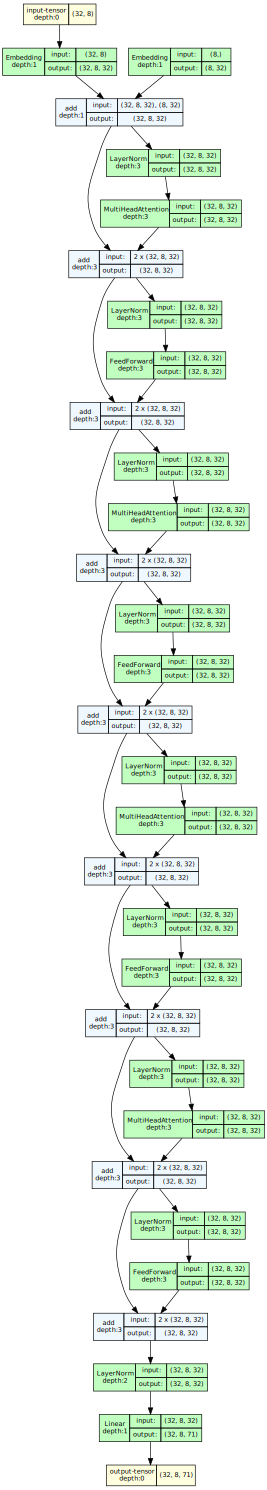

In [16]:
from torchview import draw_graph

model_graph = draw_graph(
    BigramLanguageModel(vocab_size, emb_size),
    input_size=(batch_size, block_size),
    dtypes=[torch.long]
)
model_graph.visual_graph

In [17]:
BigramLanguageModel(vocab_size, emb_size)

BigramLanguageModel(
  (token_embedding_table): Embedding(71, 32)
  (position_embedding_table): Embedding(8, 32)
  (blocks): Sequential(
    (0): TransformerBlock(
      (att_head): MultiHeadAttention(
        (heads): ModuleList(
          (0-7): 8 x Head(
            (key): Linear(in_features=32, out_features=4, bias=False)
            (query): Linear(in_features=32, out_features=4, bias=False)
            (value): Linear(in_features=32, out_features=4, bias=False)
          )
        )
        (proj): Linear(in_features=32, out_features=32, bias=True)
      )
      (feedforward): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=32, out_features=128, bias=True)
          (1): ReLU()
          (2): Linear(in_features=128, out_features=32, bias=True)
        )
      )
      (ln1): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
      (ln2): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
    )
    (1): TransformerBlock(
      (at

*note that residual connections don't show up in the architecture above*

## 13. Sanity check: untrained generation

In [18]:
model = BigramLanguageModel(vocab_size, emb_size)
model = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, max_new_tokens=200)[0].tolist()))

0.055367 M parameters
 cE6t!□W8QmW□ypO2BmY4~4■2‘RFT~cWEZ8•pCTT3Wo■xbjI3tzGxYp‘lTWO4b?R6■Jk6oNvhrBbbHvHSOEXppf~doOv?Tdp□5VFHb~Dx83PJdcLuIQc0IkHWGlPmMDEE•5vMor‘a1g•5X1lTZvRGE!t3kYzNEEforWEs•l7b3□8q4G~5TdiMgcEET7•4uT2vtgDDgpb!


## 14. Training the model

In [19]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step 0: train loss 4.4332, val loss 4.4318
step 500: train loss 2.3067, val loss 2.2895
step 1000: train loss 2.1692, val loss 2.1434
step 1500: train loss 2.0715, val loss 2.0449
step 2000: train loss 2.0081, val loss 2.0047
step 2500: train loss 1.9796, val loss 1.9700
step 3000: train loss 1.9288, val loss 1.9326
step 3500: train loss 1.9053, val loss 1.9226
step 4000: train loss 1.9002, val loss 1.8872
step 4500: train loss 1.8803, val loss 1.8821
step 5000: train loss 1.8797, val loss 1.8644
step 5500: train loss 1.8432, val loss 1.8678
step 6000: train loss 1.8472, val loss 1.8436
step 6500: train loss 1.8444, val loss 1.8437
step 7000: train loss 1.8265, val loss 1.8503
step 7500: train loss 1.8241, val loss 1.8338
step 8000: train loss 1.8272, val loss 1.8127
step 8500: train loss 1.8101, val loss 1.8176
step 9000: train loss 1.8022, val loss 1.8129
step 9500: train loss 1.7962, val loss 1.8023
step 9999: train loss 1.8171, val loss 1.7961


## 15. Generate text from the trained model

In [20]:
print('''\n##########################################
# Let's generate some Harry Potter text! #
##########################################''')
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, max_new_tokens=2000)[0].tolist()))


##########################################
# Let's generate some Harry Potter text! #
##########################################
 mudding out around a loodrely awarring led all be least and upmore they donts to stare it my chetranger said Harry . .Your .Ronose the imprirting is .tyes nearing frobly !she and sile denidnts an anouvel itmence ound Fly harde find Loockion .Are his tarrinks stared Plaw once you sharped act on shave ?Ron Ron crulledtachial to the I knew roaket ontia live shour Durny wart said Harry .Ive Ronsaugressor were to the again and so the and foor .stead and musing there been the alloward to time speater that was seall you newight a cleasted beling Voelder him Im reving and were spock red natce said Harry shining and namous ?hit ?dont found .McGone !Harry donce Potter his and too was ret geast nermilided his might sing of expace of be as could said See is metting plassed and you wankins ?Entried it hand followed .You did dearge tooked .Ill to again other will .wre gr